In [1]:
#Install & Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

import torch.optim as optim

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [9]:
import zipfile
import os

zip_path = "/cifer10.zip"     # Replace with your uploaded file name
extract_path = "./dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
import torchvision.transforms as transforms

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])


In [11]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder(
    root="./dataset/cifar10/train",
    transform=transform_train
)

test_dataset = ImageFolder(
    root="./dataset/cifar10/test",
    transform=transform_test
)

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

classes = train_dataset.classes

print("Classes:", classes)
print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training Images: 50000
Testing Images: 10000


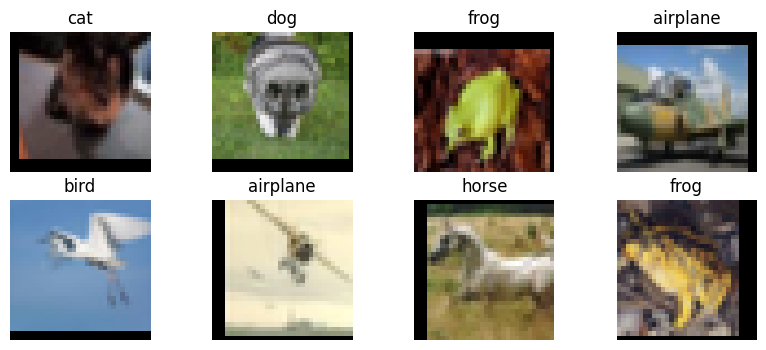

In [13]:
#Visualize the Dataset
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i].permute(1,2,0)

    img = img * torch.tensor((0.2023,0.1994,0.2010)) + \
          torch.tensor((0.4914,0.4822,0.4465))

    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

In [14]:
#Create the Early Exit Module
class EarlyExit(nn.Module):

    def __init__(self, in_channels, num_classes=10):

        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.AdaptiveMaxPool2d((1,1))

        self.fc1 = nn.Linear(in_channels,128)
        self.fc2 = nn.Linear(128,num_classes)

    def forward(self,x):

        x = F.relu(self.conv(x))

        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = F.relu(self.fc1(x))

        return self.fc2(x)

In [15]:
#Build the Main CNN Architecture
class EarlyExitCNN(nn.Module):

    def __init__(self,num_classes=10):

        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64,128,3,padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128,128,3,padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128,256,3,padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        self.conv6 = nn.Conv2d(256,256,3,padding=1)
        self.bn6 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2,2)

        self.exit1 = EarlyExit(64,num_classes)

        self.exit2 = EarlyExit(128,num_classes)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        self.fc1 = nn.Linear(256,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,num_classes)

    def forward(self,x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        out1 = self.exit1(x)

        x = F.relu(self.bn3(self.conv3(x)))

        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        out2 = self.exit2(x)

        x = F.relu(self.bn5(self.conv5(x)))

        x = self.pool(F.relu(self.bn6(self.conv6(x))))

        x = self.avgpool(x)

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        out3 = self.fc3(x)

        return out1,out2,out3

In [16]:
#Create the Model
model = EarlyExitCNN().to(device)

print(model)

EarlyExitCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

In [17]:
#Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

w1 = 0.3
w2 = 0.3
w3 = 1.0

In [18]:
#Training Loop
epochs = 20

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        exit1,exit2,final = model(images)

        loss1 = criterion(exit1,labels)
        loss2 = criterion(exit2,labels)
        loss3 = criterion(final,labels)

        loss = w1*loss1 + w2*loss2 + w3*loss3

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, Loss = {running_loss/len(train_loader):.4f}"
    )

Epoch 1/20, Loss = 2.2649
Epoch 2/20, Loss = 1.6321
Epoch 3/20, Loss = 1.3886
Epoch 4/20, Loss = 1.2416
Epoch 5/20, Loss = 1.1427
Epoch 6/20, Loss = 1.0604
Epoch 7/20, Loss = 0.9972
Epoch 8/20, Loss = 0.9575
Epoch 9/20, Loss = 0.9083
Epoch 10/20, Loss = 0.8771
Epoch 11/20, Loss = 0.8401
Epoch 12/20, Loss = 0.8141
Epoch 13/20, Loss = 0.7975
Epoch 14/20, Loss = 0.7731
Epoch 15/20, Loss = 0.7535
Epoch 16/20, Loss = 0.7285
Epoch 17/20, Loss = 0.7196
Epoch 18/20, Loss = 0.6995
Epoch 19/20, Loss = 0.6874
Epoch 20/20, Loss = 0.6696


In [19]:
#Test Accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        _,_,outputs = model(images)

        _,predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")

Test Accuracy: 80.87%


In [24]:
#Early Exit Inference
threshold = 0.90

model.eval()

image,label = test_dataset[5000]

image = image.unsqueeze(0).to(device)

with torch.no_grad():

    e1,e2,final = model(image)

    p1 = torch.softmax(e1,1)

    if p1.max() > threshold:
        print("Prediction:", p1.argmax(1).item())
        print("Exited at Exit 1")

    else:

        p2 = torch.softmax(e2,1)

        if p2.max() > threshold:

            print("Prediction:", p2.argmax(1).item())
            print("Exited at Exit 2")

        else:

            pf = torch.softmax(final,1)

            print("Prediction:", pf.argmax(1).item())
            print("Exited at Final Output")

Prediction: 5
Exited at Final Output


In [21]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/early_exit_cnn.pth"
)

print("Model saved to Google Drive!")

Model saved to Google Drive!
